In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('C:/Users/Admin/Downloads/csv_file_transformed.csv')
df.head()

,month,town,resale_price,storey_range,flat_type,flat_model,lease_commence_date,remaining_lease_years,remaining_lease_months,floor_area_sqm,...,y,latitude,longitude,closest_mrt_station,distance_to_mrt_meters,transport_type,line_color,distance_to_cbd,closest_pri_school,distance_to_pri_school_meters
0,2017-01-01,ANG MO KIO,232000.0,10 TO 12,2 ROOM,Improved,1979-05-01,61,4,44.0,...,38229.067463,1.362005,103.853880,Ang Mo Kio,999.941618,MRT,Red,8615.656983,TOWNSVILLE PRIMARY SCHOOL,218.125254
1,2017-01-01,ANG MO KIO,250000.0,01 TO 03,3 ROOM,New Generation,1978-08-01,60,7,67.0,...,39220.009892,1.370966,103.838202,Ang Mo Kio,1268.958246,MRT,Red,9715.131951,ANG MO KIO PRIMARY SCHOOL,241.572335
2,2017-01-01,ANG MO KIO,262000.0,01 TO 03,3 ROOM,New Generation,1980-06-01,62,5,67.0,...,40297.283149,1.380709,103.835368,Yio Chu Kang,1072.295164,MRT,Red,10828.819556,ANDERSON PRIMARY SCHOOL,777.155378
3,2017-01-01,ANG MO KIO,265000.0,04 TO 06,3 ROOM,New Generation,1980-02-01,62,1,68.0,...,38693.098657,1.366201,103.857201,Ang Mo Kio,945.371842,MRT,Red,9097.929095,TECK GHEE PRIMARY SCHOOL,698.165530
4,2017-01-01,ANG MO KIO,265000.0,01 TO 03,3 ROOM,New Generation,1980-06-01,62,5,67.0,...,40334.052030,1.381041,103.835132,Yio Chu Kang,1095.197729,MRT,Red,10869.453109,ANDERSON PRIMARY SCHOOL,782.553222


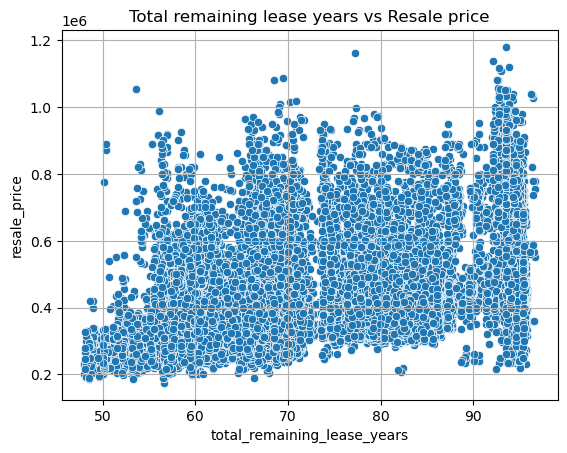

In [2]:
df['total_remaining_lease_years'] = df['remaining_lease_years'] + df['remaining_lease_months'] / 12

sns.scatterplot(data=df[0:20000], x='total_remaining_lease_years', y='resale_price')
plt.grid(True)
plt.title('Total remaining lease years vs Resale price')
plt.show()

```
Trend: 

Clear upward relationship.

Flats with longer lease years remaining (80–99 years) have higher resale prices.

Older flats (40–60 years remaining) tend to be much cheaper.

Pattern:

Prices rise sharply around 90–99 years (newer flats).

Wide spread in prices even within the same lease bucket → suggests other factors (location, size) also matter.

Conclusion:

Lease years is a strong predictor of resale price.

Buyers pay a premium for flats with a long lease.

Text(0.5, 1.0, 'DIstance_to_mrt vs Resale_price')

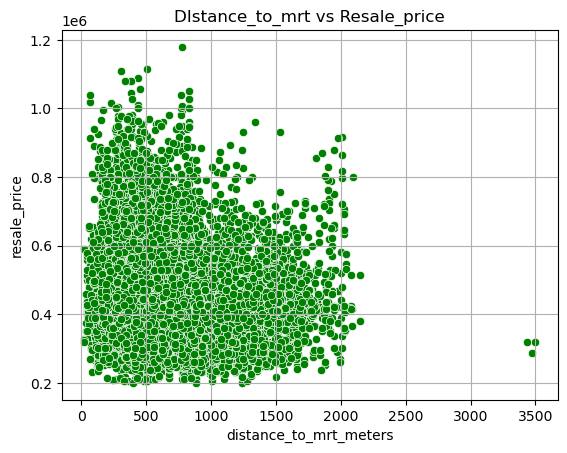

In [3]:
sns.scatterplot(data=df[0:10000], x='distance_to_mrt_meters', y='resale_price', color='green')
plt.grid()
plt.title('DIstance_to_mrt vs Resale_price')

```
Trend: Weak negative correlation.

Flats closer to MRT stations (<500m) tend to have slightly higher resale prices.

As distance increases, prices scatter more, but most remain under 1M SGD.

Pattern:

The majority of flats are within 0–1500m from MRT.

Outliers exist up to 3.5 km away (usually cheaper or special cases).

Conclusion:

Proximity to MRT matters, but less strongly than lease years.

Suggests accessibility is a secondary driver compared to flat age/lease.

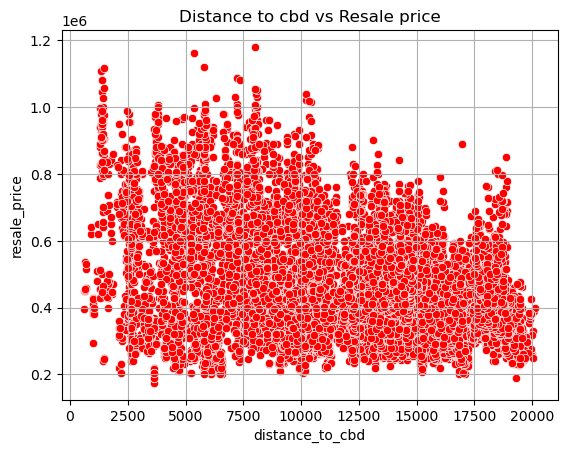

In [4]:
sns.scatterplot(data=df[0:15000], x='distance_to_cbd', y='resale_price', color='red')
plt.grid()
plt.title('Distance to cbd vs Resale price')
plt.show()

In [ ]:
```
Trend:

Very weak negative correlation. Flats nearer to the CBD (<5 km) show slightly higher resale prices, though prices are widely scattered.

As distance increases, resale prices don’t consistently fall, but the upper bound of prices (>1M SGD) becomes less common further away.

Pattern:

Most resale flats are priced between 200K–800K SGD, regardless of CBD distance.

Dense cluster of transactions lies within 0–12 km of the CBD.

Outliers exist up to 20 km away, but these rarely exceed 1M SGD.

Conclusion:

Proximity to CBD has some influence, but resale prices are more affected by other factors (e.g., lease years, flat size, amenities).

Accessibility to the city center is important but not the dominant driver.

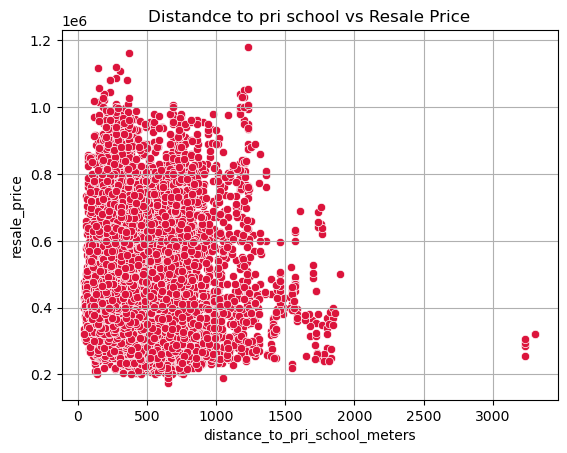

In [5]:
sns.scatterplot(data=df[0:15000], x='distance_to_pri_school_meters', y='resale_price', color='crimson')
plt.title('Distandce to pri school vs Resale Price')
plt.grid()
plt.show()

In [6]:
pd.crosstab(index=df['flat_type'], columns=df['line_color'])

line_color,Blue,Brown,Green,Grey,Orange,Purple,Red
flat_type,,,,,,,
1 ROOM,0,0,78,0,0,0,0
2 ROOM,349,95,776,1254,164,84,1484
3 ROOM,6215,1149,14854,4411,2764,5409,15799
4 ROOM,7270,1950,19164,23079,3374,9057,26108
5 ROOM,4843,1326,11525,14857,1809,3820,14138
EXECUTIVE,1917,380,3894,2853,478,1433,4457
MULTI-GENERATION,26,0,0,0,0,0,58


In [7]:
pd.crosstab(index=df['flat_model'], columns=df['flat_type'])

flat_type,1 ROOM,2 ROOM,3 ROOM,4 ROOM,5 ROOM,EXECUTIVE,MULTI-GENERATION
flat_model,,,,,,,
2-room,0,311,0,0,0,0,0
3Gen,0,0,0,0,62,0,0
Adjoined flat,0,0,0,32,205,126,0
Apartment,0,0,0,0,0,7735,0
DBSS,0,2,477,1410,1547,0,0
Improved,78,555,12254,2314,36826,0,0
Improved-Maisonette,0,0,0,0,30,0,0
Maisonette,0,0,0,0,0,5898,0
Model A,0,2666,14873,55455,2644,0,0


Text(0.5, 1.0, 'Distribution of FLat models by Transport type')

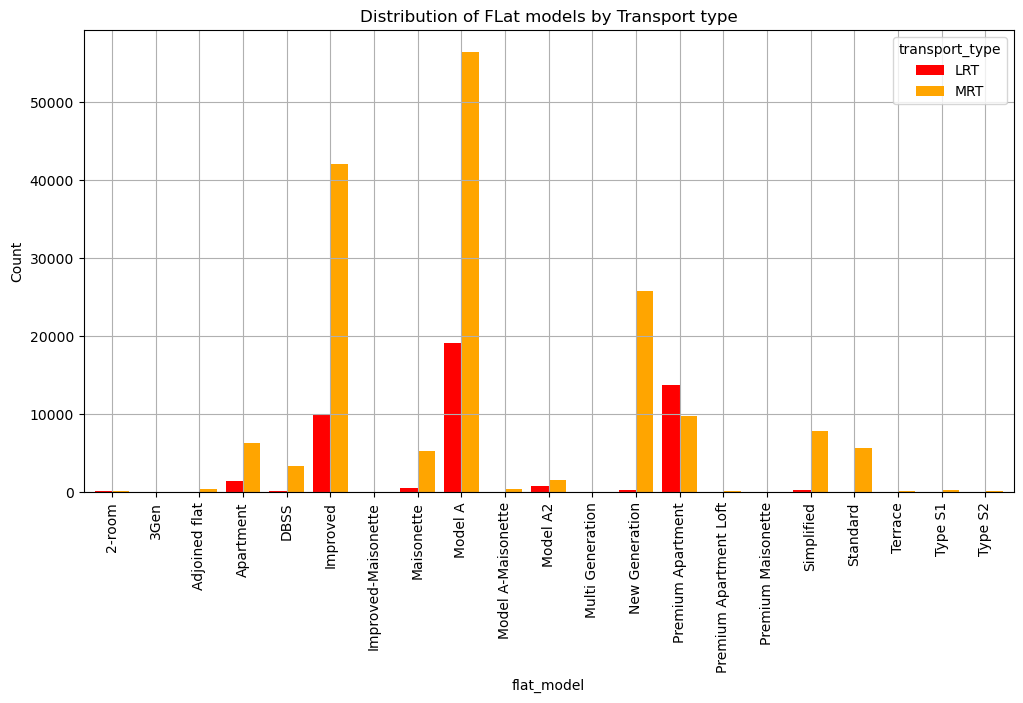

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))
pd.crosstab(index=df['flat_model'], columns=df['transport_type']).plot(kind='bar', width=0.8, color=['red', 'orange'], ax=ax)
plt.ylabel('Count')
plt.grid()
plt.title('Distribution of FLat models by Transport type')

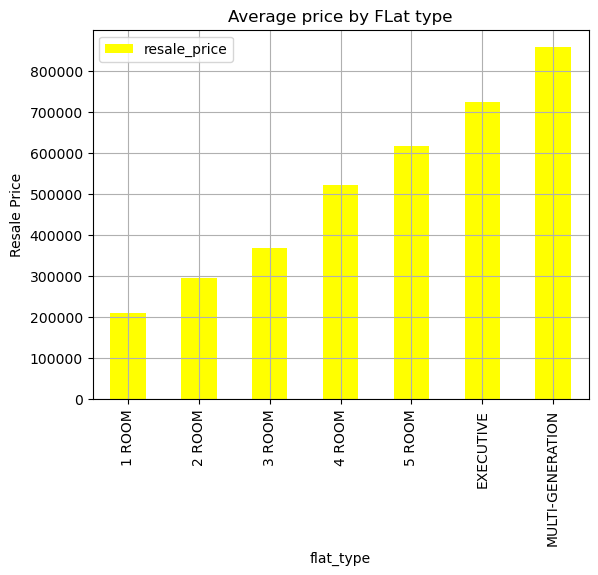

In [10]:
pd.pivot_table(df, values='resale_price', index='flat_type', aggfunc='mean').plot(kind='bar', color='yellow')
plt.title('Average price by FLat type')
plt.grid()
plt.ylabel('Resale Price')
plt.show()

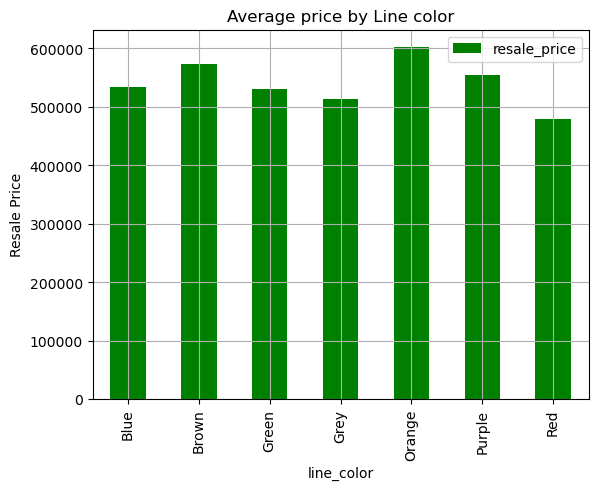

In [11]:
pd.pivot_table(df, values='resale_price', index='line_color', aggfunc='mean').plot(kind='bar', color='green')
plt.title('Average price by Line color')
plt.grid()
plt.ylabel('Resale Price')
plt.show()

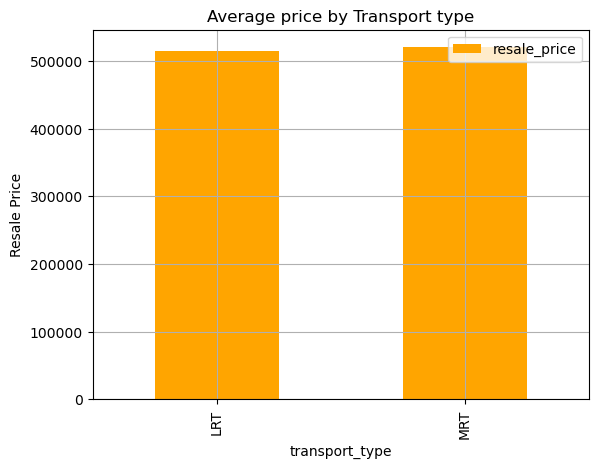

In [12]:
pd.pivot_table(df, values='resale_price', index='transport_type', aggfunc='mean').plot(kind='bar', color='orange')
plt.grid()
plt.title('Average price by Transport type')
plt.ylabel('Resale Price')
plt.show()

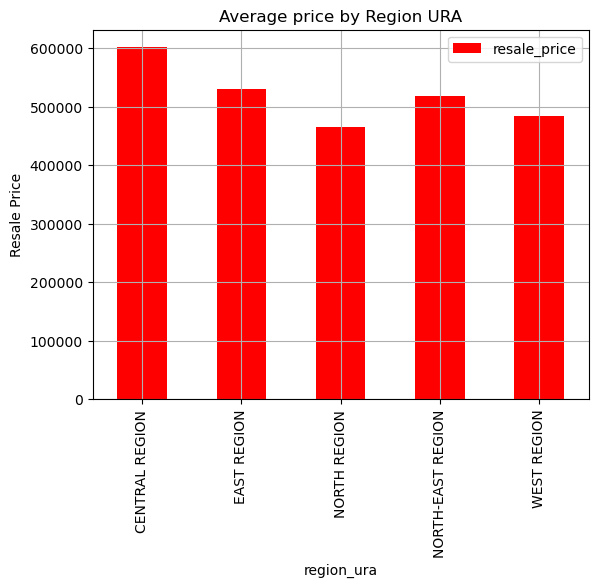

In [13]:
pd.pivot_table(df, values='resale_price', index='region_ura', aggfunc='mean').plot(kind='bar', color='red')
plt.grid()
plt.ylabel('Resale Price')
plt.title('Average price by Region URA')
plt.show()

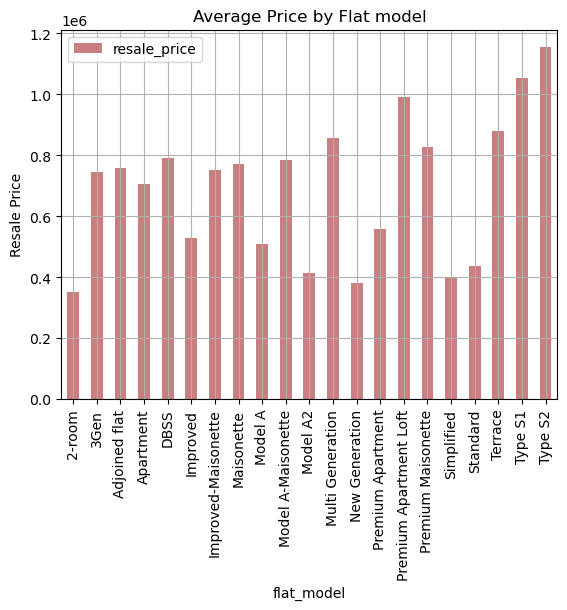

In [14]:
pd.pivot_table(df, values='resale_price', index='flat_model', aggfunc='mean').plot(kind='bar', color='brown', alpha=0.6)
plt.title('Average Price by Flat model')
plt.ylabel('Resale Price')
plt.grid()
plt.show()

Text(0.5, 0.98, 'Pairplot of Important features')

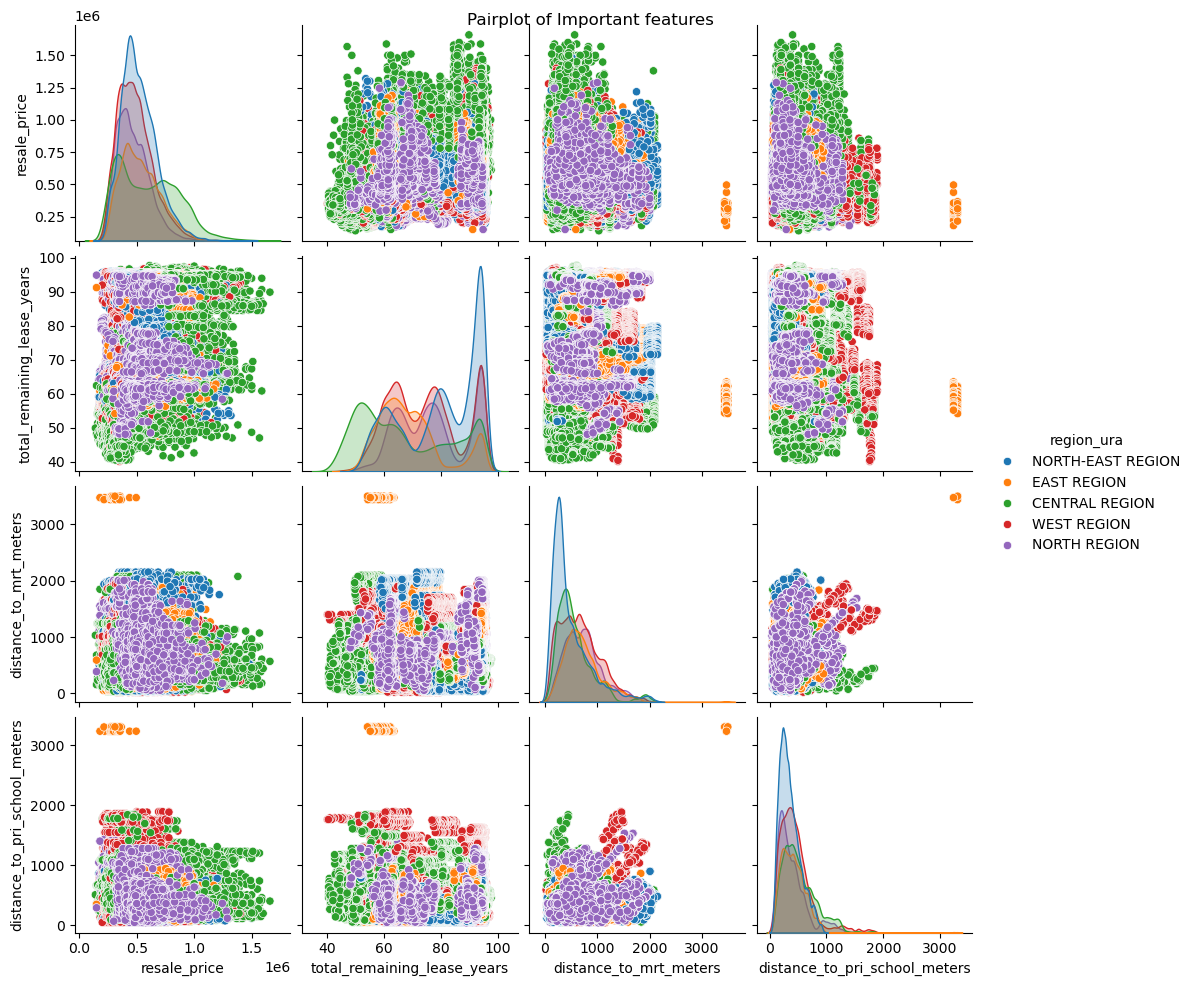

In [27]:
sns.pairplot(df, vars=['resale_price', 'total_remaining_lease_years', 'distance_to_mrt_meters', 'distance_to_pri_school_meters'], hue='region_ura')
plt.suptitle('Pairplot of Important features')

```
Resale price: Right-skewed — most flats sell around 0.3–0.6 million SGD, with fewer above 1 million SGD.

Remaining lease years: Strong peaks at 70–90 years (younger flats) and around 40–60 years (older flats).

Distance to MRT & Primary Schools: Heavily concentrated near 0–1000 meters → many flats are close to transport and schools.

...

Resale price vs Lease years: Positive relationship — newer flats (longer lease) tend to fetch higher prices.

Resale price vs Distance to MRT: Weak negative relationship — closer to MRT stations tends to mean higher price.

Resale price vs Distance to Primary School: Also weak negative — proximity to schools slightly increases resale price.

Lease years vs Distances: No clear correlation (distances are not strongly tied to lease age).

...

Central Region (green):

Concentrated in the higher price range, even for similar lease years or distances.

Indicates a premium effect of central location.

East & West Regions (orange, red):

Generally lower prices compared to Central, for similar features.

North & North-East (blue, purple):

Clustered around lower–mid prices, more spread out in distances.

...

Strong predictors:

total_remaining_lease_years (positive correlation with resale price).

region_ura (captures location premium, especially Central).

Moderate predictors:

distance_to_mrt_meters, distance_to_pri_school_meters (closer → higher price, but effect is weaker).

Noise considerations:

Distances show wide spread with overlapping regions → may add noise if not normalized or combined with location.



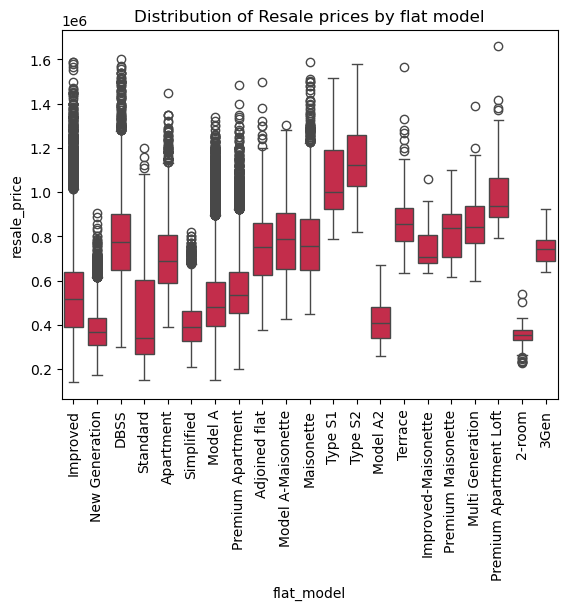

In [16]:
sns.boxplot(data=df, x='flat_model', y='resale_price', color='crimson')
plt.title('Distribution of Resale prices by flat model')
plt.xticks(rotation=90)
plt.show()

```
Low-priced segment:

2-room flats: Lowest prices overall (~200K–400K).

Clear outliers, but median is far below other models.

Mid-range segment:

Improved, New Generation, Standard, Model A, Simplified, Apartment:

Median resale prices ~400K–600K.

Wide spread, many outliers crossing 1M (esp. New Generation, Apartment, Standard).

These are the bulk of resale flats.

Higher-priced flats:

Maisonettes (Adjoined, Model A, Improved, Premium, etc.) and Terrace:

Median resale prices closer to ~700K–900K.

Some reach 1.4M+.

Clearly more expensive housing options.

Premium flats:

Premium Apartment, Premium Maisonette, Multi Generation, Premium Apartment Loft:

Medians ~900K–1.1M.

Very wide spread — some above 1.5M.

These are the top-end of the resale market.

Special cases:

DBSS (Design, Build and Sell Scheme):

Very high variability.

Many outliers, but central tendency shows them as more expensive than standard flats.

Basic flats like 2-room, Improved, and Standard dominate the mid-range resale market (400K–600K), whereas Maisonettes, DBSS, and Premium models command much higher resale prices, often exceeding 1M.

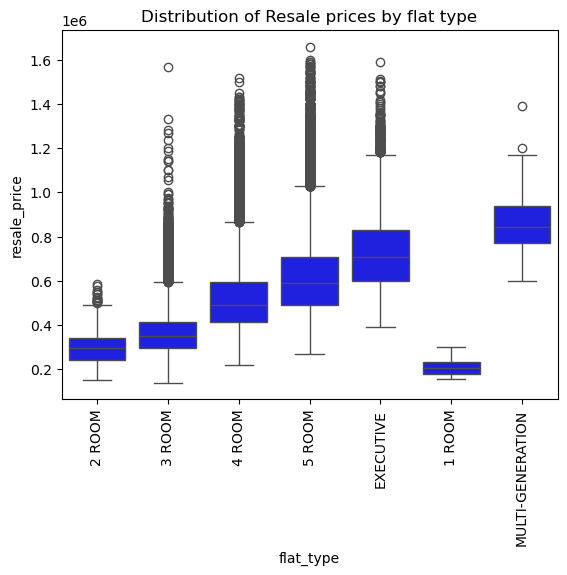

In [17]:
sns.boxplot(data=df, x='flat_type', y='resale_price', color='blue')
plt.title('Distribution of Resale prices by flat type')
plt.xticks(rotation=90)
plt.show()

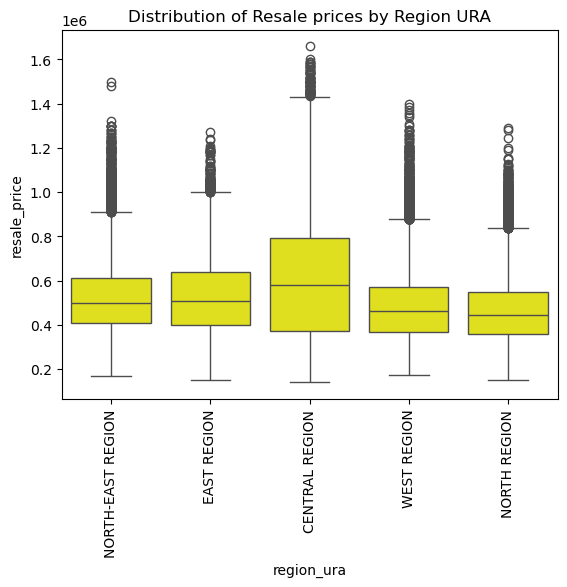

In [18]:
sns.boxplot(data=df, x='region_ura', y='resale_price', color='yellow')
plt.title('Distribution of Resale prices by Region URA')
plt.xticks(rotation=90)
plt.show()

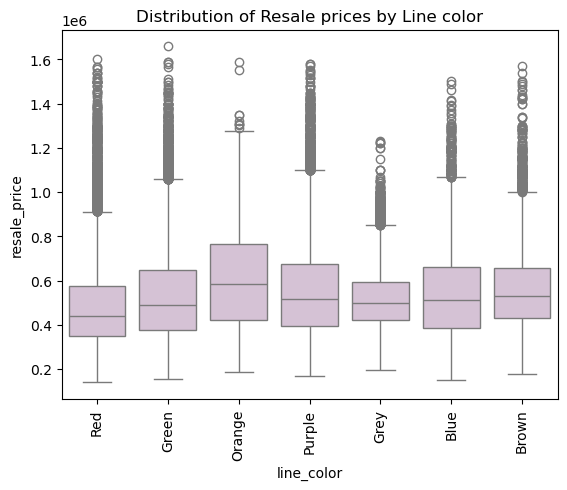

In [19]:
sns.boxplot(data=df, x='line_color', y='resale_price', color='thistle')
plt.title('Distribution of Resale prices by Line color')
plt.xticks(rotation=90)
plt.show()

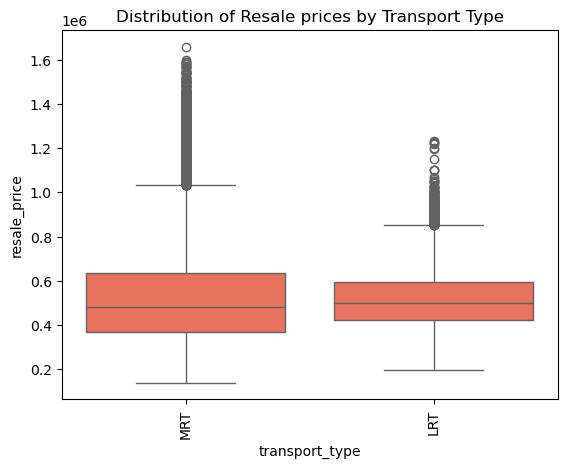

In [20]:
sns.boxplot(data=df, x='transport_type', y='resale_price', color='tomato')
plt.title('Distribution of Resale prices by Transport Type')
plt.xticks(rotation=90)
plt.show()

```
Most houses near MRT stations are priced between 380K and 620K, although a smaller number of properties exceed this range and can cost significantly more.

<Axes: xlabel='resale_price', ylabel='Count'>

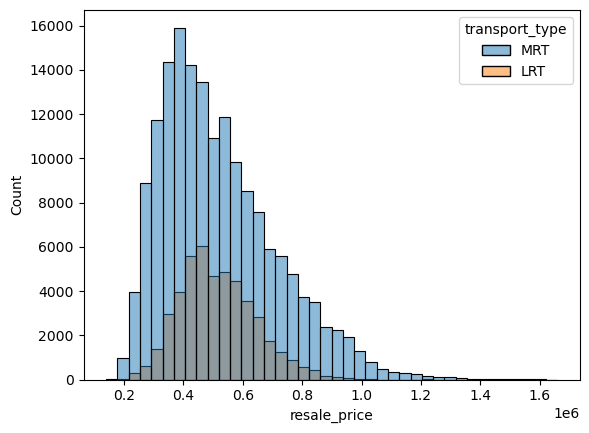

In [21]:
sns.histplot(data=df, x='resale_price', hue='transport_type', alpha=0.5, bins=40)

```
The shape is right-skewed (long tail to the right).

As we saw in Boxplot, most resale flats cluster between 370K-380K to 600K-620K.

Few flats exceed 1M, showing high-end outliers.

Accessibility to MRT is a more prevalent factor in resale flats than LRT. However, both transport types show similar price behavior, peaking around 400K–500K.



<Axes: xlabel='resale_price', ylabel='Count'>

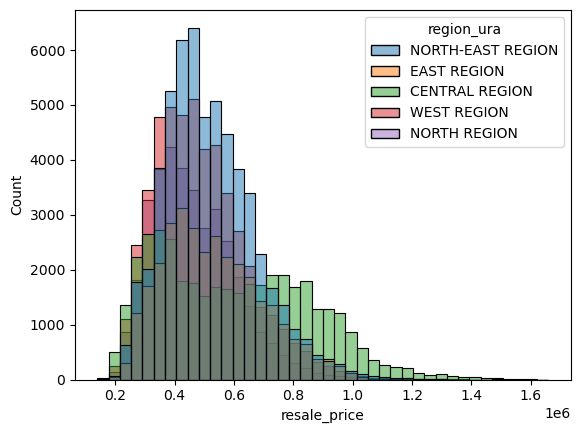

In [22]:
sns.histplot(data=df, x='resale_price', hue='region_ura', alpha=0.5, bins=40)

```
Central & East regions tend to have higher resale prices, aligning with their urban importance and demand.

North, West, and North-East regions dominate the mid-range (350K–600K).

The general market median lies around 450K–500K, with location playing a strong role in the likelihood of higher resale values.

<Axes: >

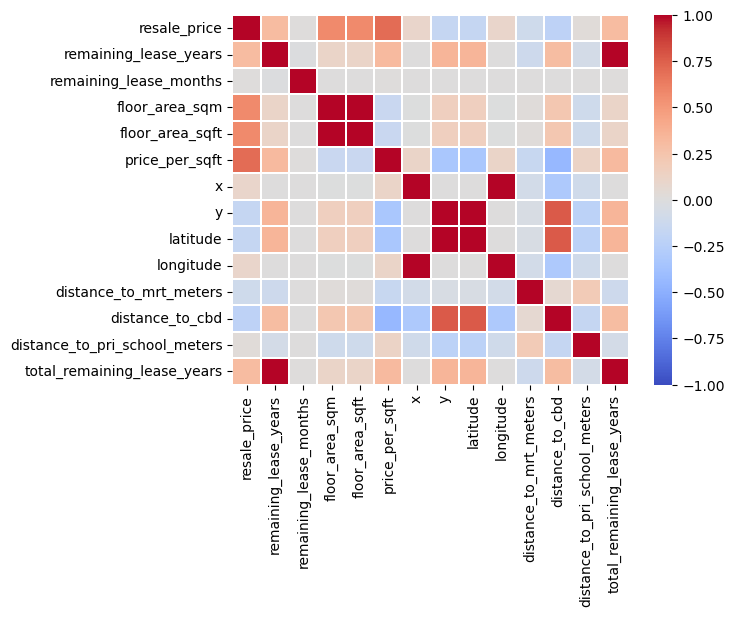

In [24]:
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', vmin=-1, vmax=1, linewidth=0.3)

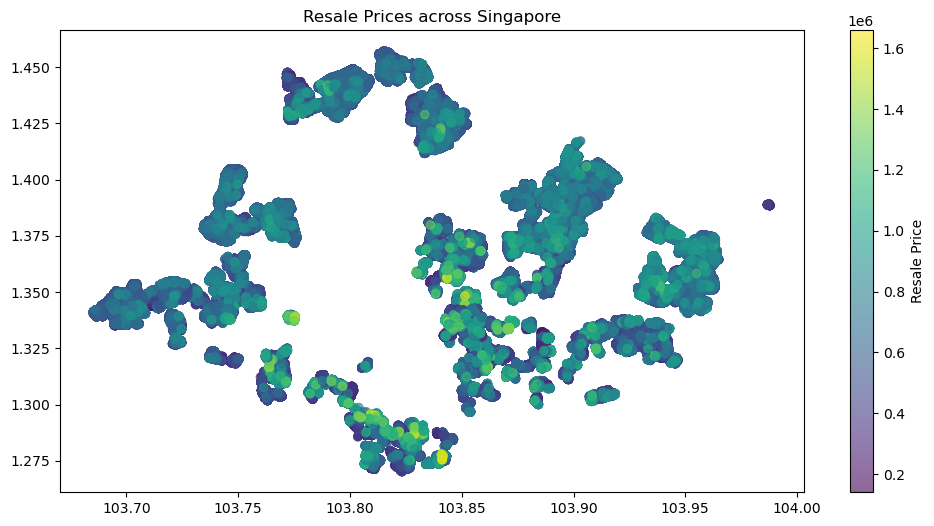

In [30]:
plt.figure(figsize=(12, 6))
plt.scatter(df['longitude'], df['latitude'], c=df['resale_price'], cmap='viridis', alpha=0.6)
plt.colorbar(label="Resale Price")
plt.title("Resale Prices across Singapore")
plt.show()

```
Shape of Singapore emerges

- Housing clusters follow HDB towns (e.g., Ang Mo Kio, Tampines, Jurong).

- Gaps correspond to non-residential areas (parks, industrial land, reservoirs).

Price distribution by region

- Central region → brighter colors → higher resale prices.

- North & West → darker colors → lower resale prices.

Density clusters

- Large, dense clusters show where major HDB estates are located.

...


Location Premium: Flats closer to the Central Business District (CBD) are consistently more expensive.

Town Effect: Mature estates like Bishan, Queenstown, Bukit Merah show higher values.

Accessibility Impact: Northern & western estates (e.g., Yishun, Jurong, Woodlands) remain more affordable.